# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [117]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [118]:
#!rm SUSY.csv

In [119]:
#!gunzip SUSY.csv.gz

In [120]:
ls -lh

 Volume in drive C is Acer
 Volume Serial Number is 3A5C-C08F

 Directory of c:\DATA 3402\DATA3402.Spring.2026\Labs\Lab.7



File Not Found


The data is provided as a comma separated file.

In [121]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

'head' is not recognized as an internal or external command,
operable program or batch file.


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [122]:
!ls -lh

'ls' is not recognized as an internal or external command,
operable program or batch file.


We see that we have 5 million datapoints.

In [123]:
!wc -l SUSY.csv

'wc' is not recognized as an internal or external command,
operable program or batch file.


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [124]:
!head -500000 SUSY.csv > SUSY-small.csv

'head' is not recognized as an internal or external command,
operable program or batch file.


In [125]:
ls -lh

File Not Found

 Volume in drive C is Acer
 Volume Serial Number is 3A5C-C08F

 Directory of c:\DATA 3402\DATA3402.Spring.2026\Labs\Lab.7



In [126]:
! wc -l SUSY-small.csv

'wc' is not recognized as an internal or external command,
operable program or batch file.


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [127]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [128]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [129]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [130]:
FeatureNames

['M_R',
 'cos_theta_r1',
 'axial_MET',
 'S_R',
 'M_TR_2',
 'dPhi_r_b',
 'MT2',
 'MET_rel',
 'R',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [132]:
filename = r"C:\DATA 3402\DATA3402.Spring.2026\Labs\Lab.7\SUSY.csv.gz"
df = pd.read_csv(filename, dtype='float64', names=VarNames, compression='gzip')

You can see the data in Jupyter by just evaluateing the dataframe:

In [133]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [134]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


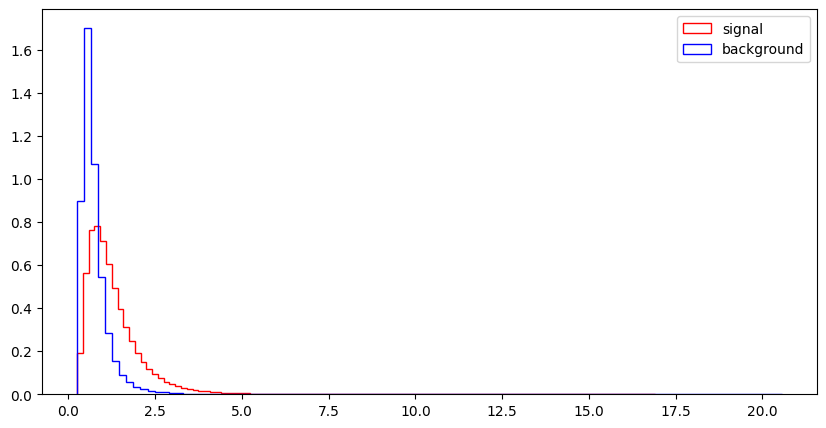

l_1_eta


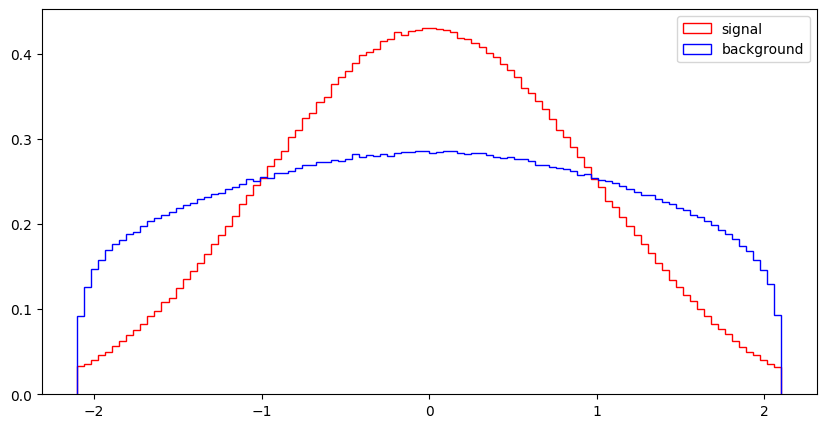

l_1_phi


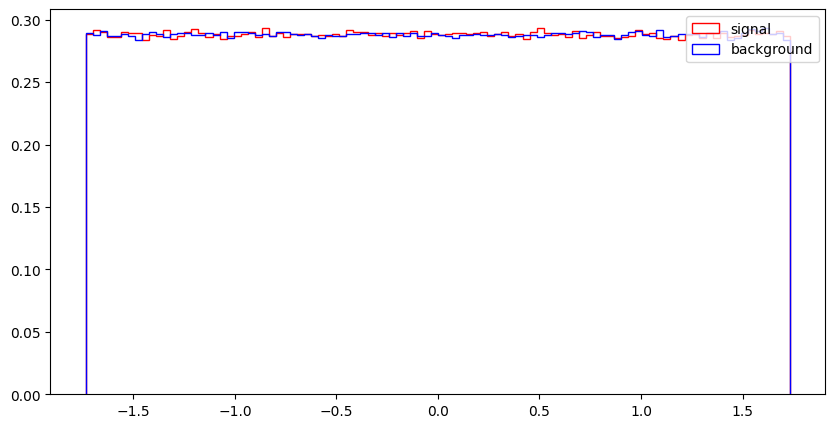

l_2_pT


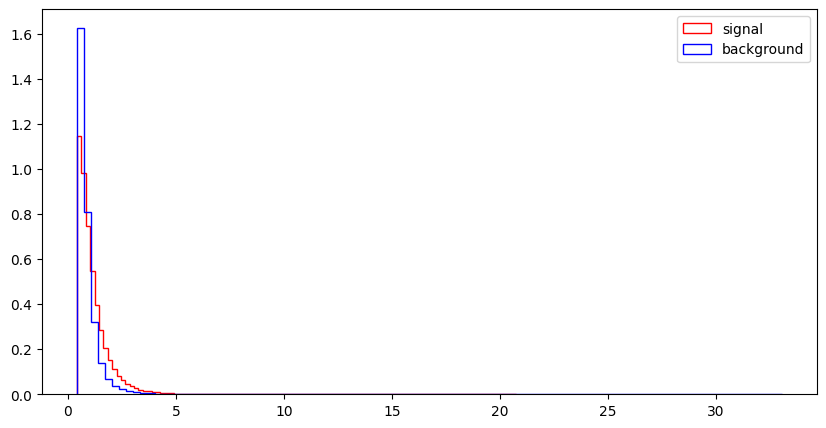

l_2_eta


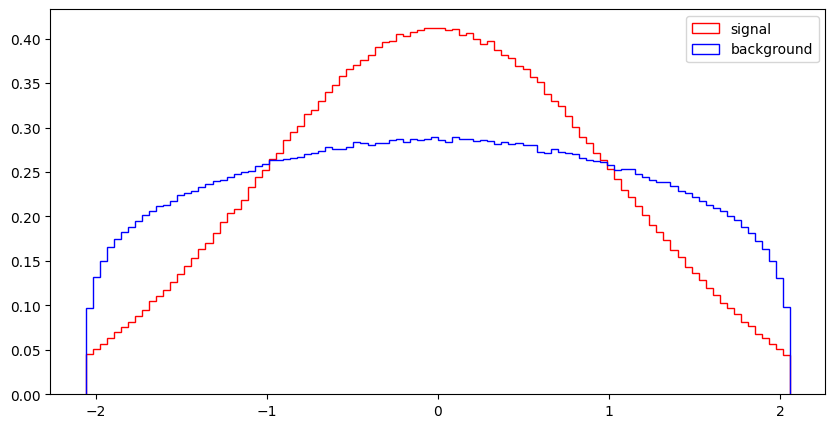

l_2_phi


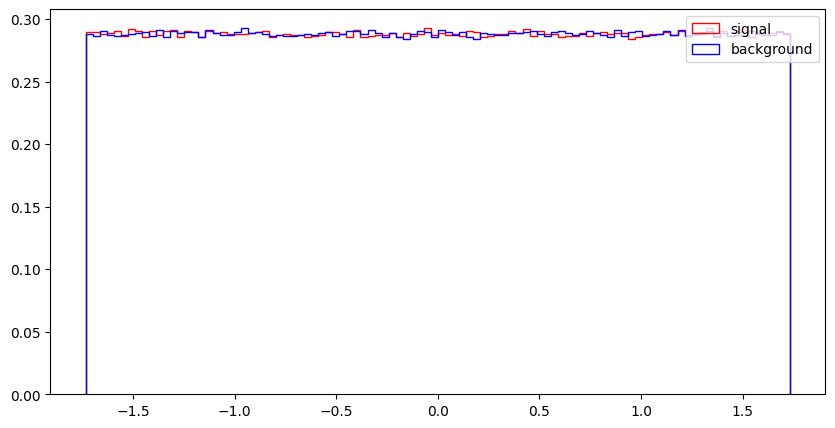

MET


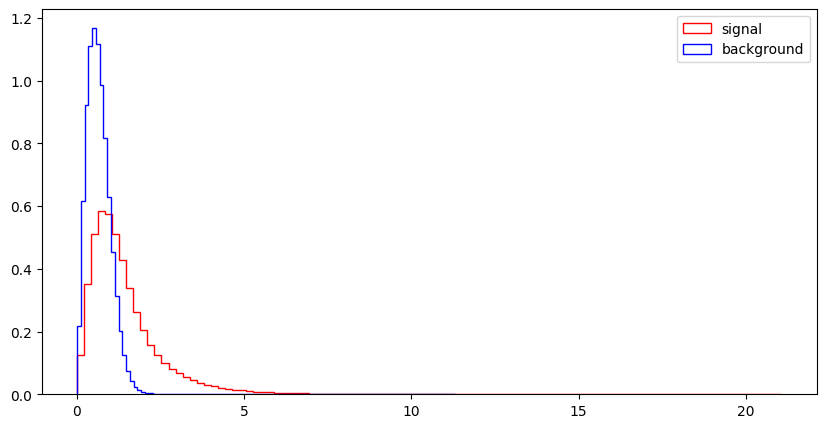

MET_phi


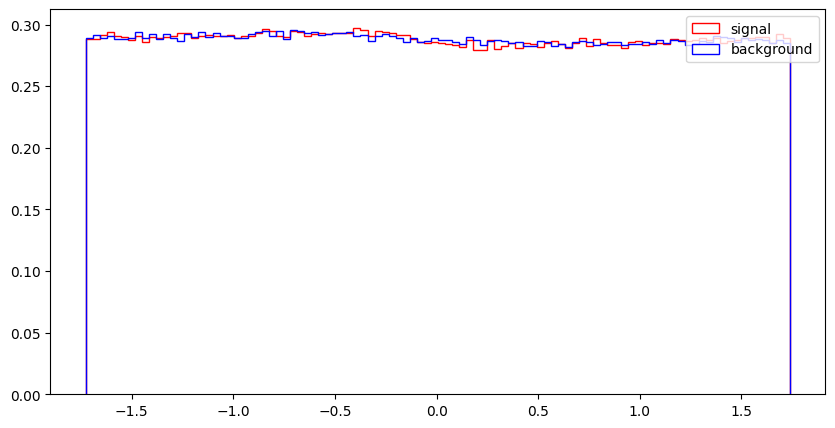

MET_rel


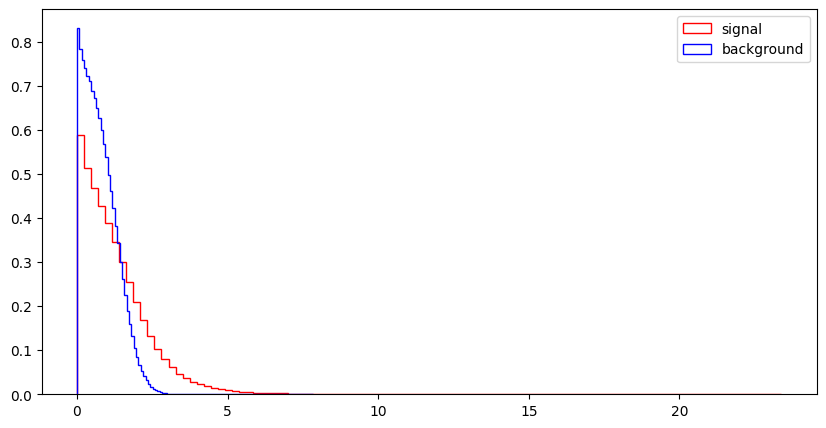

axial_MET


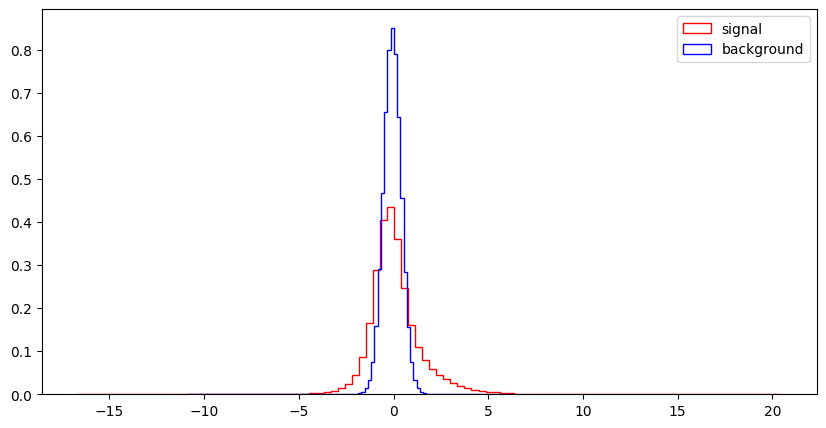

M_R


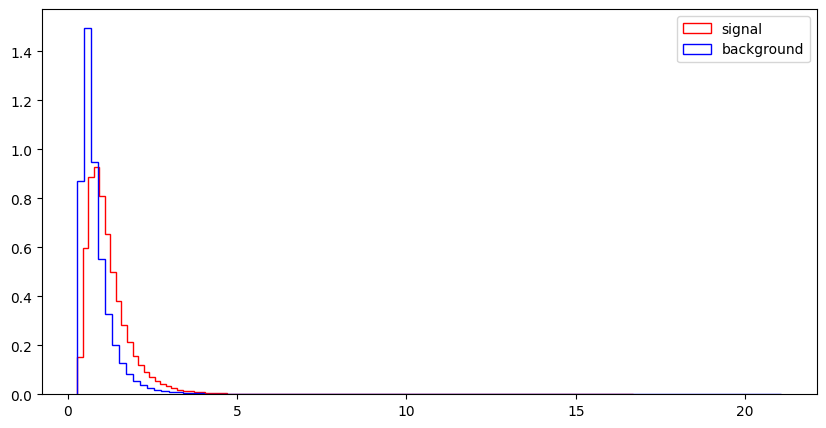

M_TR_2


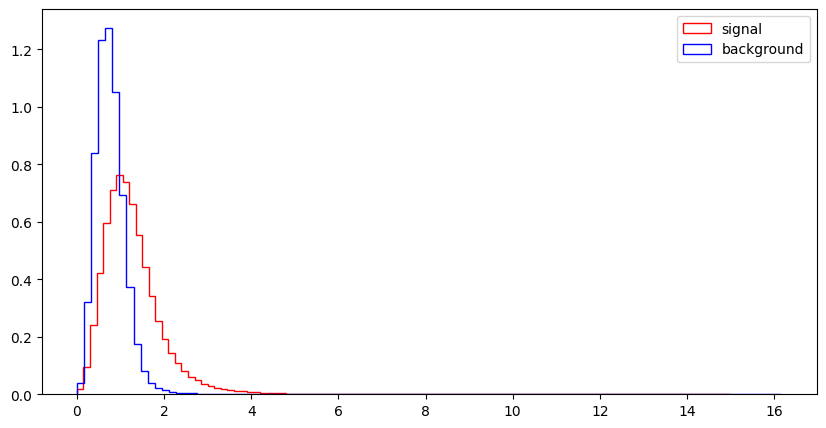

R


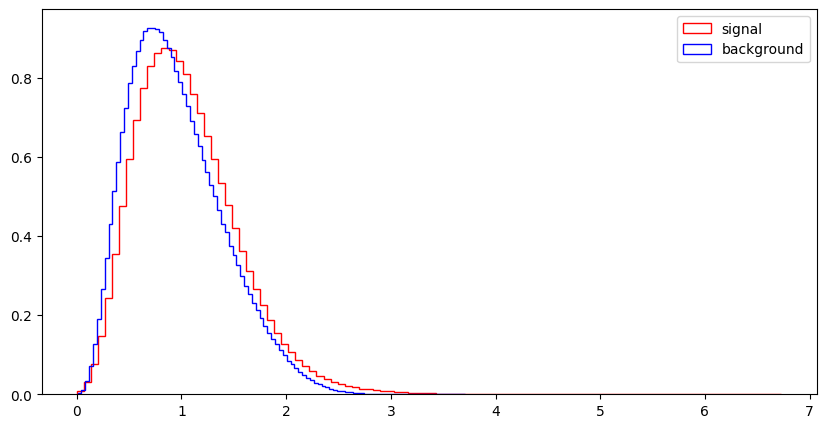

MT2


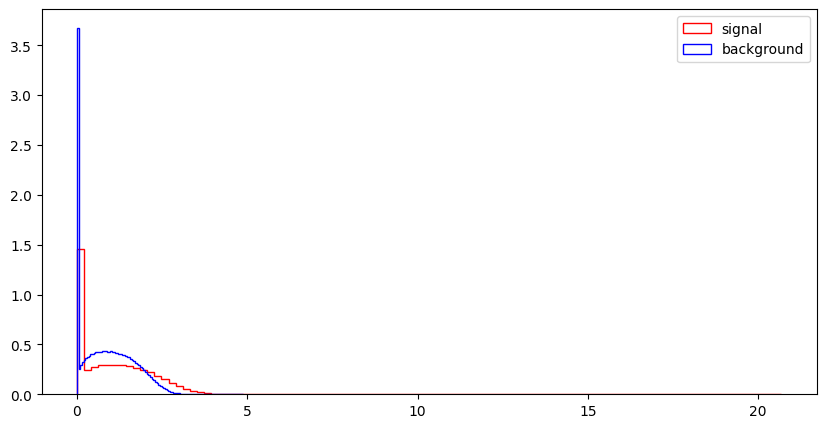

S_R


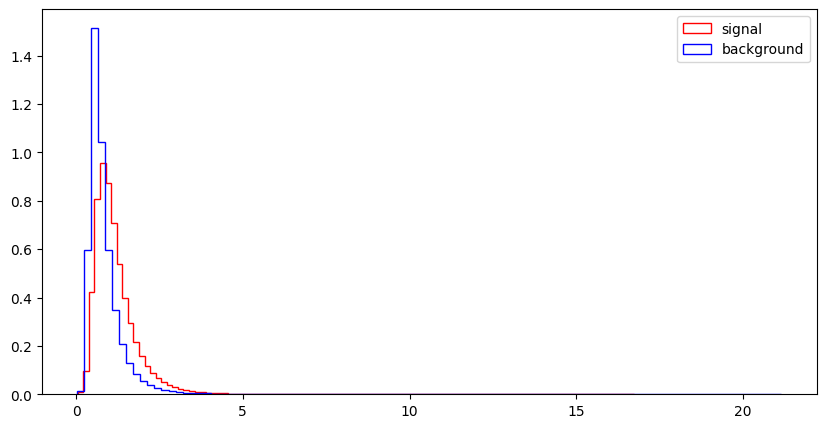

M_Delta_R


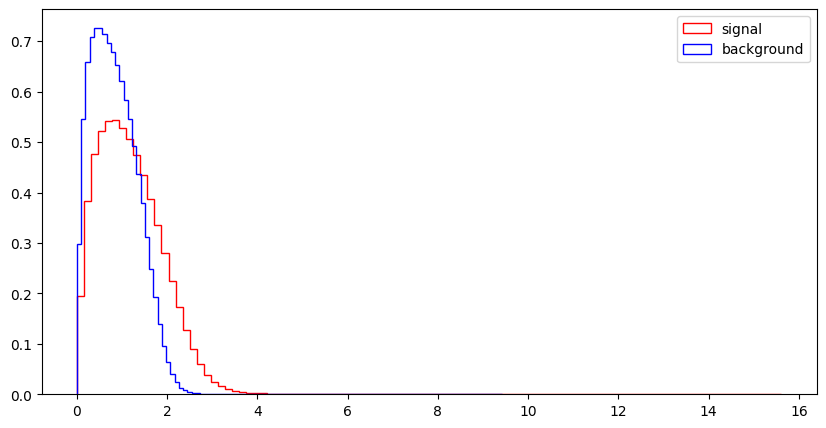

dPhi_r_b


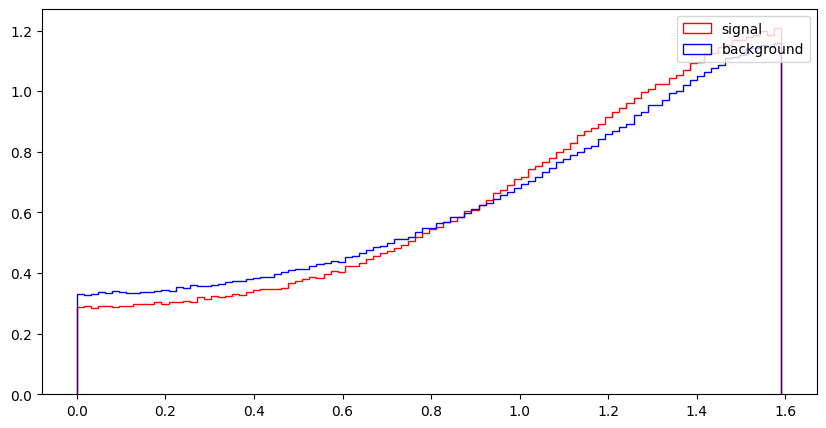

cos_theta_r1


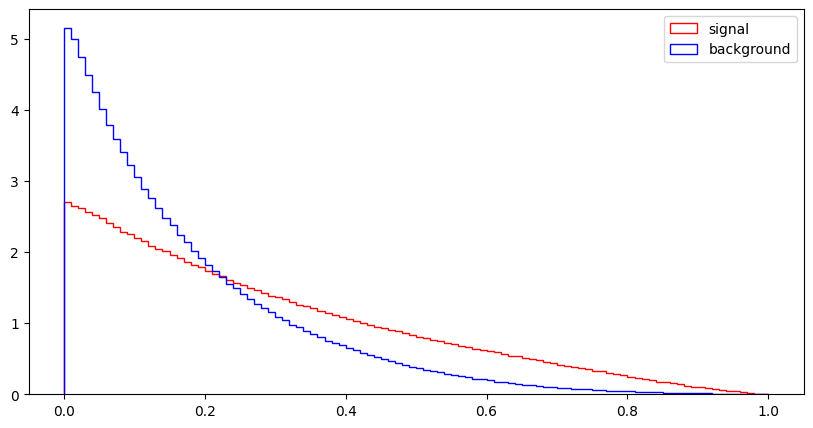

In [135]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

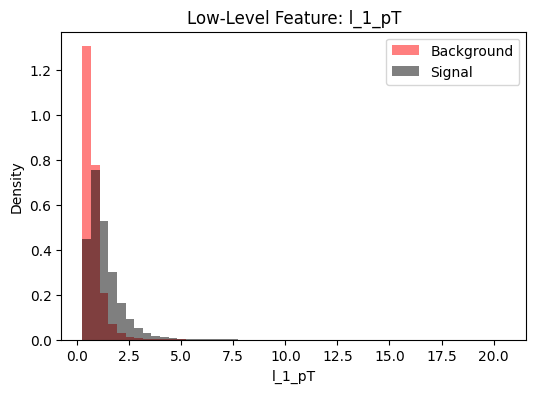

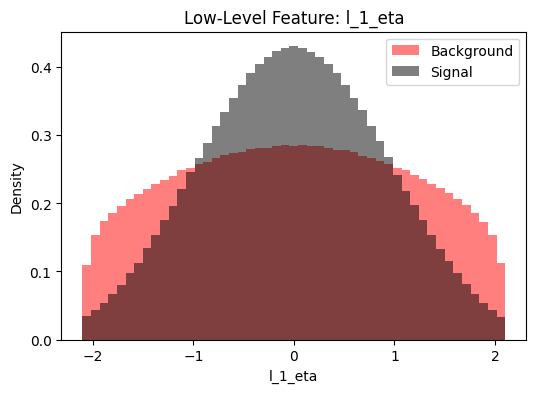

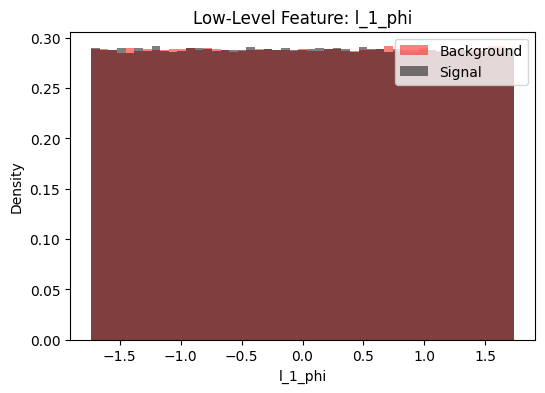

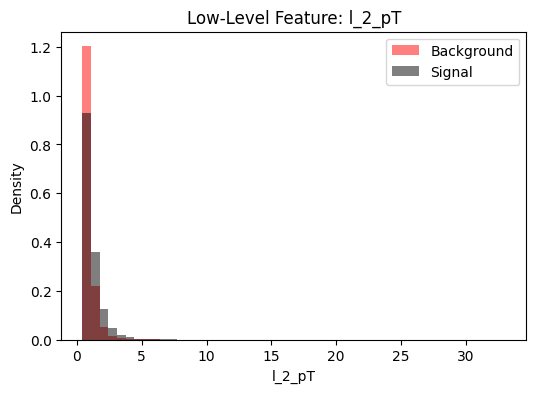

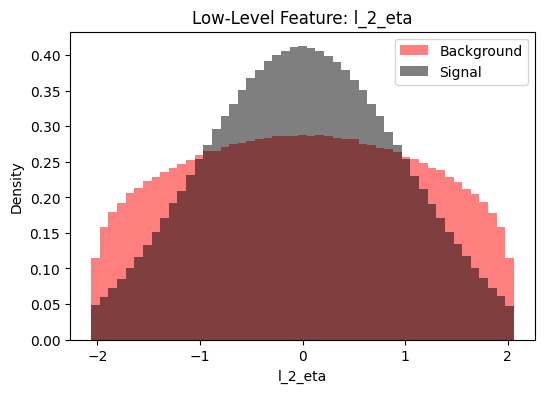

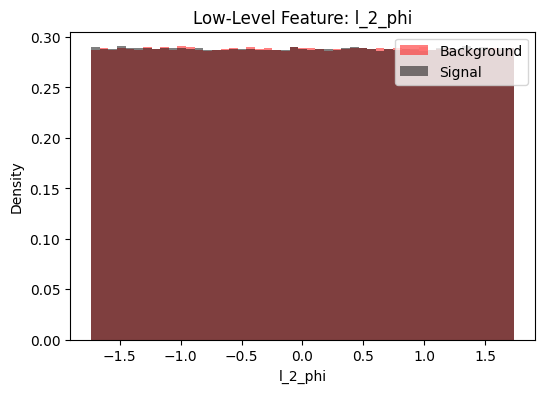

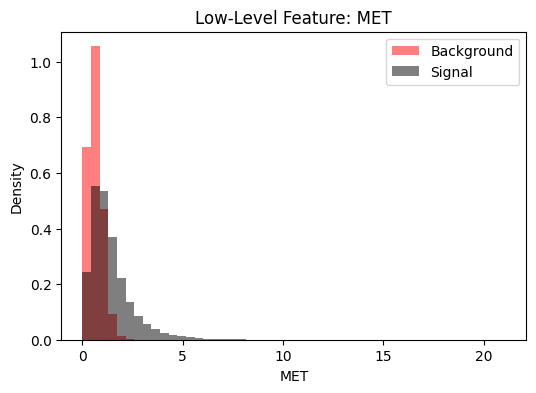

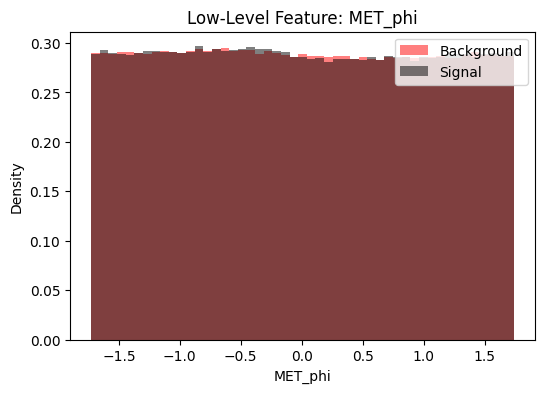

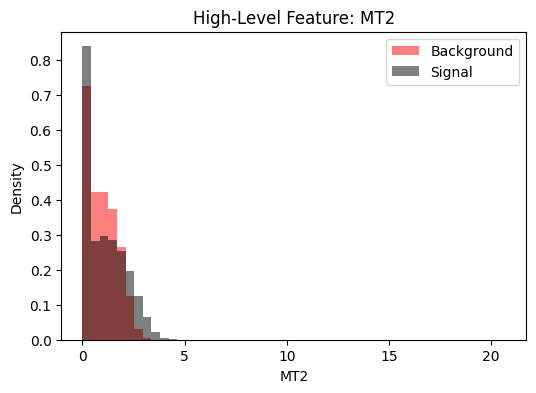

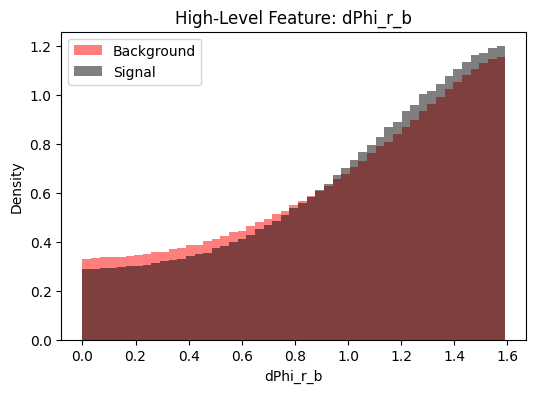

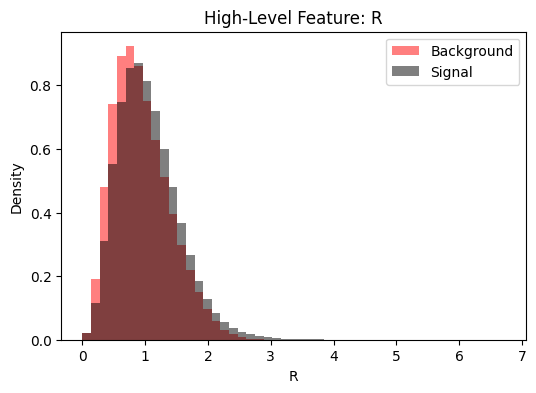

In [136]:
low_level_features = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi'] # These are the raw features directly measured by the detector.
high_level_features = ['MT2', 'dPhi_r_b', 'R']

for feature in low_level_features: # Plot histograms for low-level features
    bins = np.linspace(df[feature].min(), df[feature].max(), 50) # Create bins based on the feature's range
    plt.figure(figsize=(6,4))
    plt.hist(df_bkg[feature], bins=bins, density=True, color='red', alpha=0.5, label='Background')
    plt.hist(df_sig[feature], bins=bins, density=True, color='black', alpha=0.5, label='Signal')
    
    plt.xlabel(feature) # Label the x-axis with the feature name
    plt.ylabel('Density')
    plt.title(f'Low-Level Feature: {feature}')
    plt.legend()
    plt.show()

for feature in high_level_features: # Plot histograms for high-level features
    bins = np.linspace(df[feature].min(), df[feature].max(), 50) # Create bins based on the feature's range
    plt.figure(figsize=(6,4))
    plt.hist(df_bkg[feature], bins=bins, density=True, color='red', alpha=0.5, label='Background')
    plt.hist(df_sig[feature], bins=bins, density=True, color='black', alpha=0.5, label='Signal')
    
    plt.xlabel(feature) # Label the x-axis with the feature name
    plt.ylabel('Density')
    plt.title(f'High-Level Feature: {feature}')
    plt.legend()
    plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

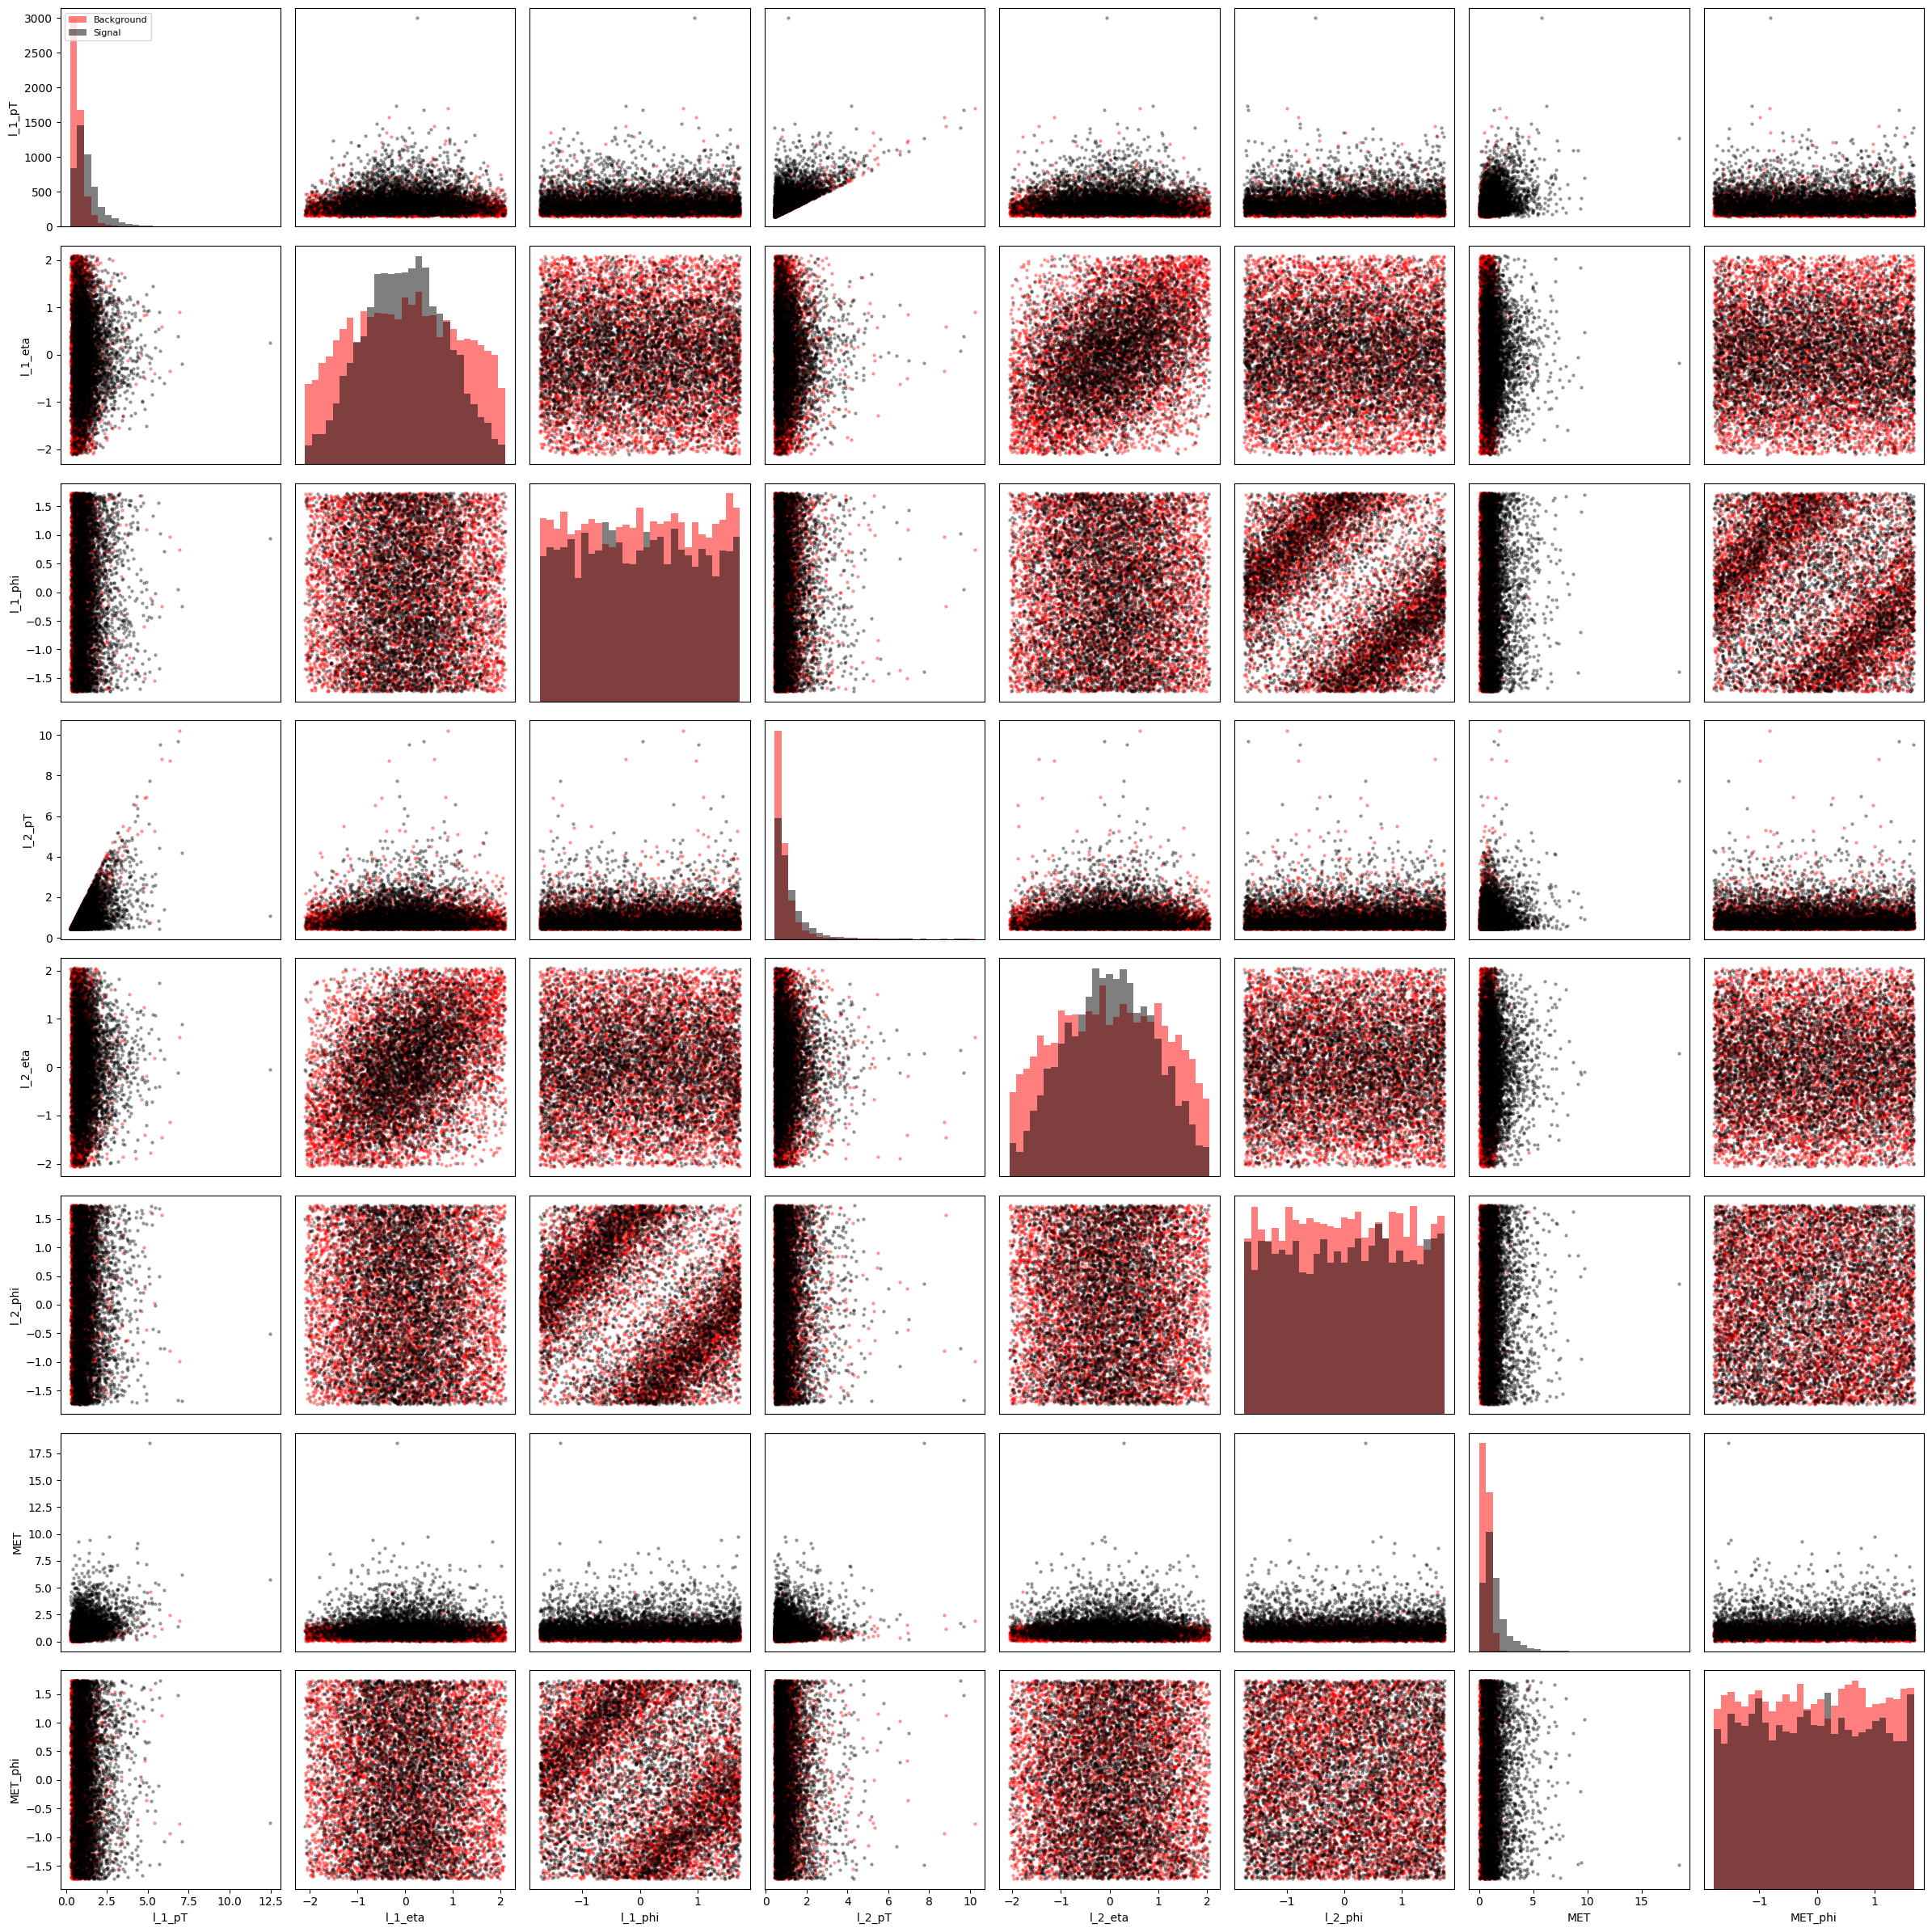

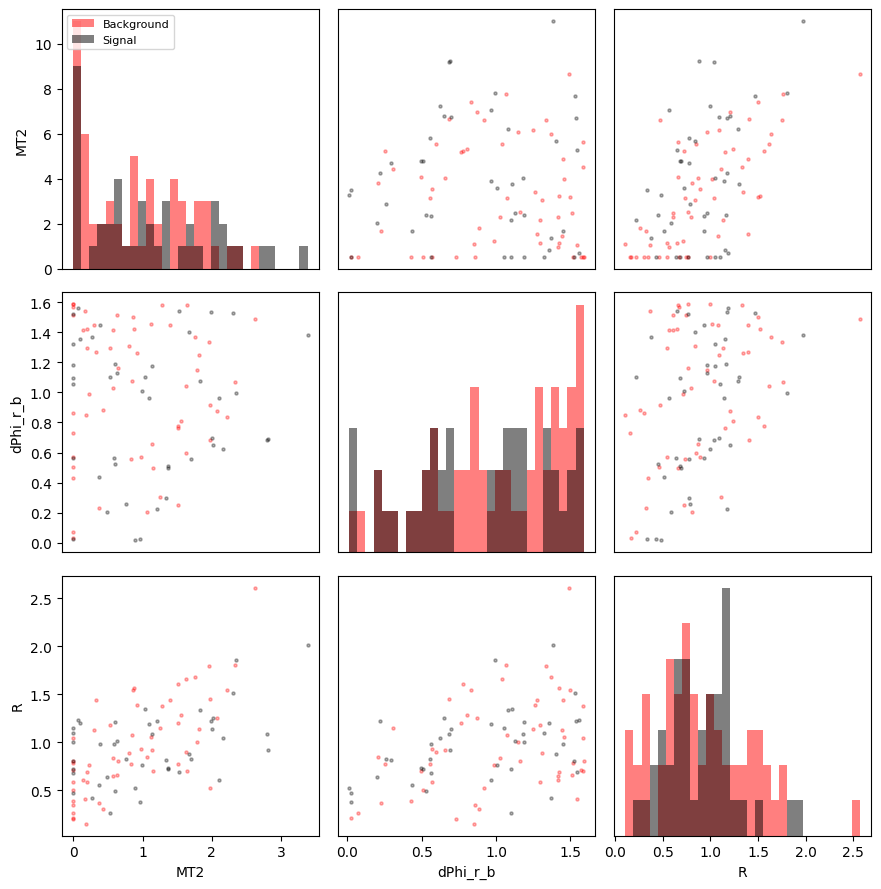

'I used a sample size of 10,000 for the low-level features and 100 for the high-level features to speed up the plotting.\nYou can use 2D histograms instead of scatter plots or binned density plots as faster alternatives.\nHigh-level features may show clearer separation between signal and background, while low-level features may be more mixed.'

In [137]:
import matplotlib.pyplot as plt
import numpy as np

def pair_plot(df, features, label_col='signal', sample_size=None): # A custom pair plot function that is more efficient for large datasets
    if sample_size is not None and sample_size < len(df):
        df = df.sample(sample_size, random_state=42)
    
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    
    data = df[features].to_numpy()
    labels = df[label_col].to_numpy()
    
    for i in range(n): # Loop over rows of the grid
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                bins = np.linspace(np.min(data[:, j]), np.max(data[:, j]), 30)
                hist_bg, _ = np.histogram(data[labels==0, j], bins=bins)
                hist_sig, _ = np.histogram(data[labels==1, j], bins=bins)
                width = bins[1]-bins[0]
                ax.bar(bins[:-1], hist_bg, width=width, color='red', alpha=0.5, label='Background')
                ax.bar(bins[:-1], hist_sig, width=width, color='black', alpha=0.5, label='Signal')
            else:
                ax.scatter(data[labels==0, j], data[labels==0, i], color='red', s=5, alpha=0.3)
                ax.scatter(data[labels==1, j], data[labels==1, i], color='black', s=5, alpha=0.3)
            
            if i == n-1:
                ax.set_xlabel(features[j])
            else:
                ax.set_xticks([])
            if j == 0:
                ax.set_ylabel(features[i])
            else:
                ax.set_yticks([])
    
    axes[0,0].legend(loc='upper left', fontsize=8) # Add legend to the top-left subplot
    plt.tight_layout()
    plt.show()

pair_plot(df, low_level_features, label_col='signal', sample_size=10000) # Use a smaller sample size for low-level features to speed up the plotting
pair_plot(df, high_level_features, label_col='signal', sample_size=100)

'''I used a sample size of 10,000 for the low-level features and 100 for the high-level features to speed up the plotting.
You can use 2D histograms instead of scatter plots or binned density plots as faster alternatives.
High-level features may show clearer separation between signal and background, while low-level features may be more mixed.'''

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [138]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [139]:
def cov_corr_tables(df, features, label=None, floatfmt=".3f", tablefmt="html"): #function that computes covariance and correlation matrices for the specified features, optionally filtering by a label (e.g., signal only), and formats the results as tables using the tabulate library for display
    data = df[features].copy() # Select only the specified features from the DataFrame
    if label is not None:
        data = data[df[label] == 1]

    X = data.to_numpy() # Convert the selected features to a numpy array for covariance and correlation calculations
    
    cov_matrix = np.cov(X, rowvar=False) # Compute the covariance matrix using numpy's cov function, with rowvar=False to indicate that variables are in columns
    
    corr_matrix = np.corrcoef(X, rowvar=False) # Compute the correlation matrix using numpy's corrcoef function, with rowvar=False to indicate that variables are in columns
    
    headers = features # Use the feature names as headers for the tables
    cov_table = tabulate.tabulate(cov_matrix, headers=headers, floatfmt=floatfmt, tablefmt=tablefmt)
    corr_table = tabulate.tabulate(corr_matrix, headers=headers, floatfmt=floatfmt, tablefmt=tablefmt)
    
    display(HTML(f"<h3>Covariance Matrix</h3>{cov_table}")) # Display the covariance matrix in the notebook using HTML formatting
    display(HTML(f"<h3>Correlation Matrix</h3>{corr_table}"))
    
    return cov_matrix, corr_matrix # Return the covariance and correlation matrices as numpy arrays

all_features = low_level_features + high_level_features # Combine low-level and high-level features into a single list for analysis

cov_all, corr_all = cov_corr_tables(df, all_features) # Compute and display covariance and correlation tables for all features combined
cov_low, corr_low = cov_corr_tables(df, low_level_features)
cov_high, corr_high = cov_corr_tables(df, high_level_features)

l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MT2,dPhi_r_b,R
0.472,-0.000,-0.000,0.308,-0.000,0.000,0.231,-0.001,-0.013,-0.047,-0.059
-0.000,1.006,0.000,-0.000,0.406,0.000,-0.001,-0.001,-0.000,0.000,0.000
-0.000,0.000,1.003,-0.000,0.001,-0.268,0.001,-0.184,0.002,0.001,0.001
0.308,-0.000,-0.000,0.428,-0.000,0.000,0.080,-0.001,-0.069,-0.004,-0.099
-0.000,0.406,0.001,-0.000,1.006,-0.000,0.000,-0.000,-0.000,-0.000,0.000
0.000,0.000,-0.268,0.000,-0.000,1.003,0.000,-0.034,0.001,0.000,0.000
0.231,-0.001,0.001,0.080,0.000,0.000,0.762,-0.002,0.156,0.145,0.189
-0.001,-0.001,-0.184,-0.001,-0.000,-0.034,-0.002,1.003,0.001,-0.001,-0.000
-0.013,-0.000,0.002,-0.069,-0.000,0.001,0.156,0.001,0.738,0.021,0.232
-0.047,0.000,0.001,-0.004,-0.000,0.000,0.145,-0.001,0.021,0.190,0.087


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MT2,dPhi_r_b,R
1.000,-0.000,-0.000,0.685,-0.000,0.000,0.385,-0.001,-0.022,-0.157,-0.183
-0.000,1.000,0.000,-0.001,0.403,0.000,-0.001,-0.001,-0.000,0.000,0.000
-0.000,0.000,1.000,-0.000,0.001,-0.267,0.001,-0.184,0.002,0.002,0.002
0.685,-0.001,-0.000,1.000,-0.001,0.000,0.140,-0.002,-0.123,-0.014,-0.322
-0.000,0.403,0.001,-0.001,1.000,-0.000,0.000,-0.000,-0.000,-0.000,0.001
0.000,0.000,-0.267,0.000,-0.000,1.000,0.000,-0.034,0.001,0.001,0.000
0.385,-0.001,0.001,0.140,0.000,0.000,1.000,-0.002,0.209,0.382,0.459
-0.001,-0.001,-0.184,-0.002,-0.000,-0.034,-0.002,1.000,0.001,-0.003,-0.000
-0.022,-0.000,0.002,-0.123,-0.000,0.001,0.209,0.001,1.000,0.056,0.574
-0.157,0.000,0.002,-0.014,-0.000,0.001,0.382,-0.003,0.056,1.000,0.424


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
0.472,-0.000,-0.000,0.308,-0.000,0.000,0.231,-0.001
-0.000,1.006,0.000,-0.000,0.406,0.000,-0.001,-0.001
-0.000,0.000,1.003,-0.000,0.001,-0.268,0.001,-0.184
0.308,-0.000,-0.000,0.428,-0.000,0.000,0.080,-0.001
-0.000,0.406,0.001,-0.000,1.006,-0.000,0.000,-0.000
0.000,0.000,-0.268,0.000,-0.000,1.003,0.000,-0.034
0.231,-0.001,0.001,0.080,0.000,0.000,0.762,-0.002
-0.001,-0.001,-0.184,-0.001,-0.000,-0.034,-0.002,1.003


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
1.000,-0.000,-0.000,0.685,-0.000,0.000,0.385,-0.001
-0.000,1.000,0.000,-0.001,0.403,0.000,-0.001,-0.001
-0.000,0.000,1.000,-0.000,0.001,-0.267,0.001,-0.184
0.685,-0.001,-0.000,1.000,-0.001,0.000,0.140,-0.002
-0.000,0.403,0.001,-0.001,1.000,-0.000,0.000,-0.000
0.000,0.000,-0.267,0.000,-0.000,1.000,0.000,-0.034
0.385,-0.001,0.001,0.140,0.000,0.000,1.000,-0.002
-0.001,-0.001,-0.184,-0.002,-0.000,-0.034,-0.002,1.000


MT2,dPhi_r_b,R
0.738,0.021,0.232
0.021,0.190,0.087
0.232,0.087,0.222


MT2,dPhi_r_b,R
1.000,0.056,0.574
0.056,1.000,0.424
0.574,0.424,1.000


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

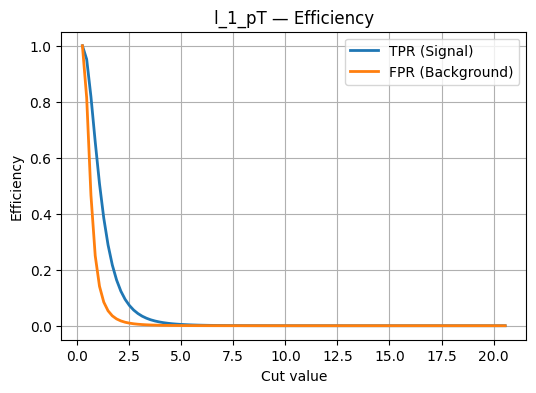

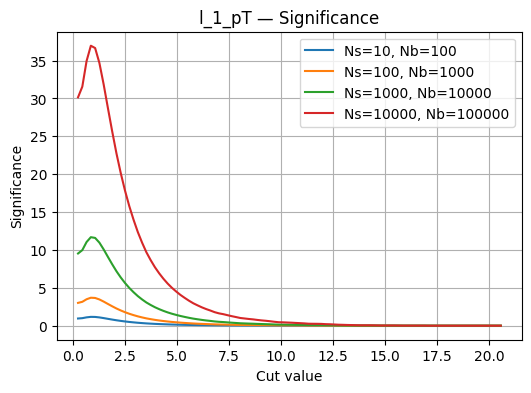

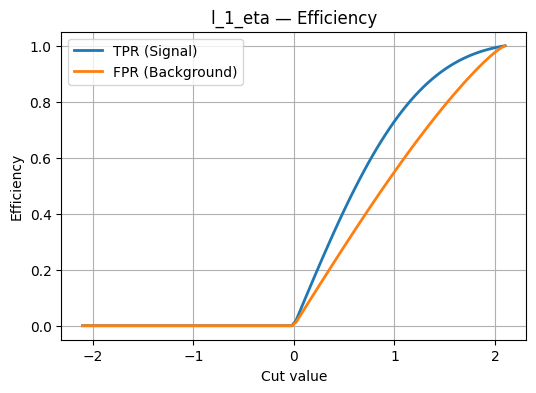

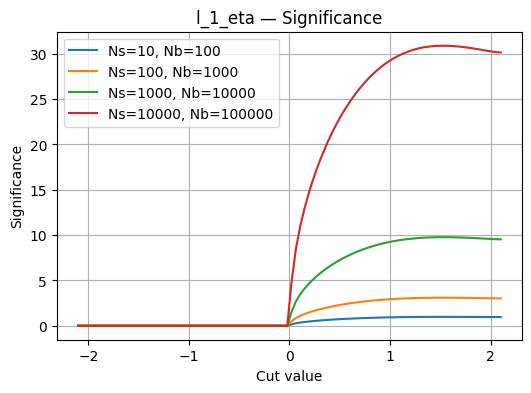

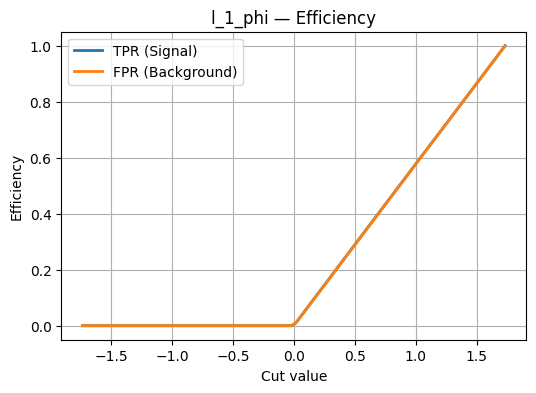

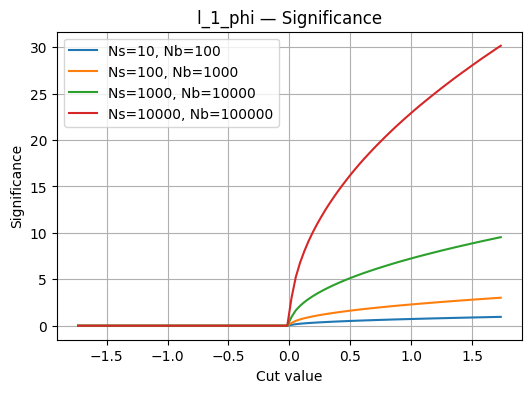

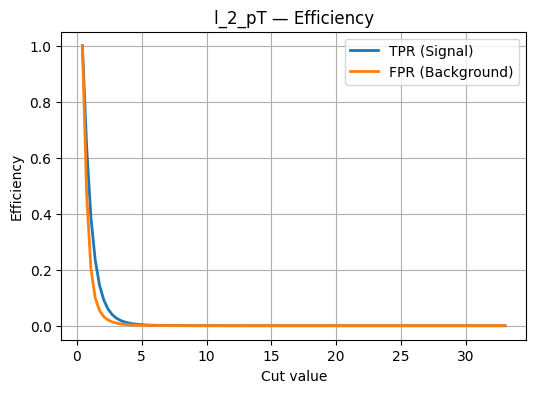

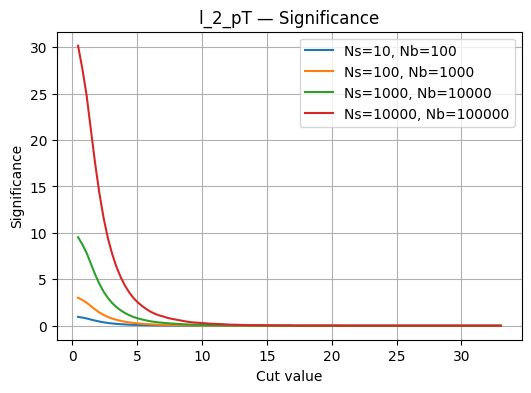

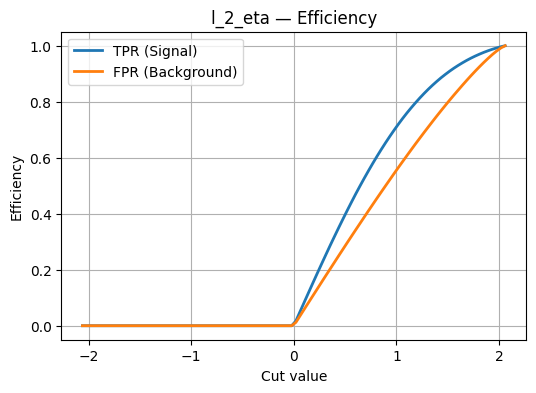

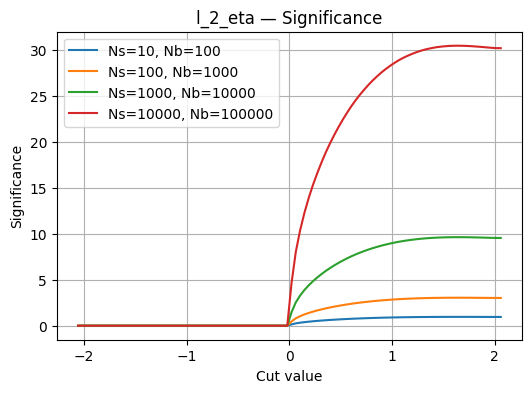

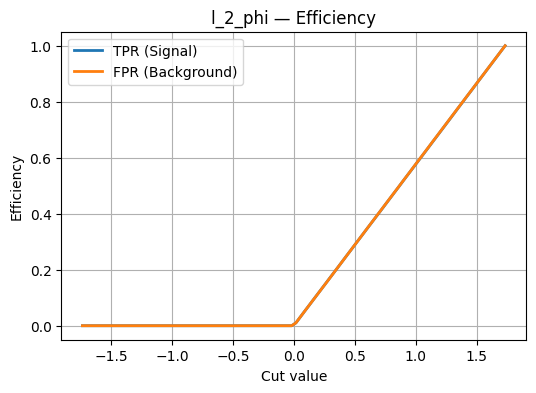

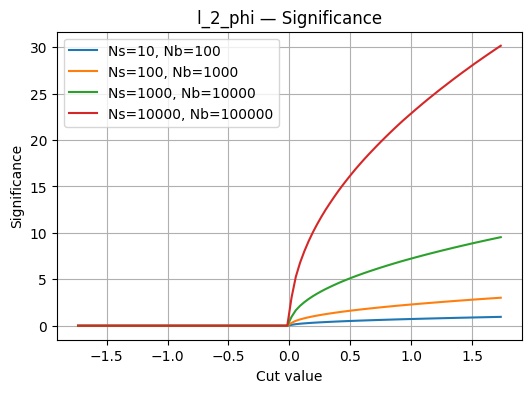

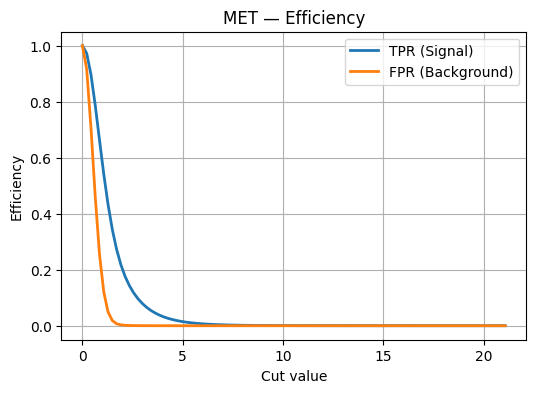

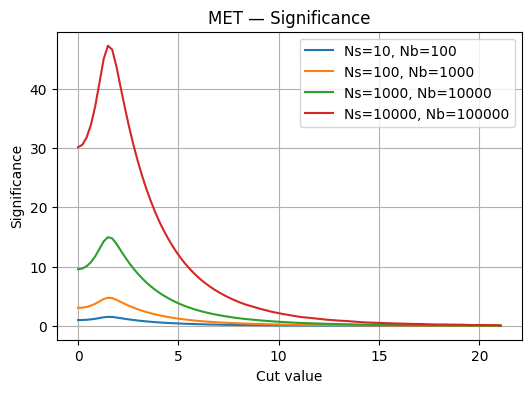

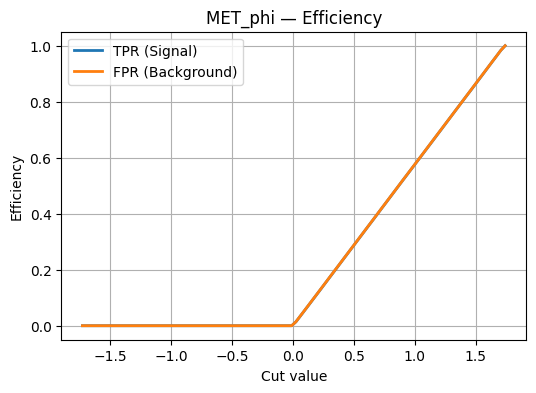

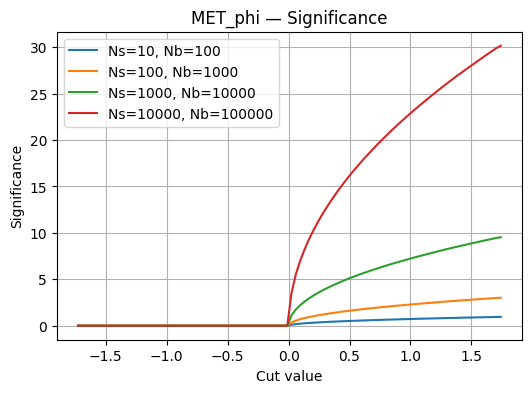

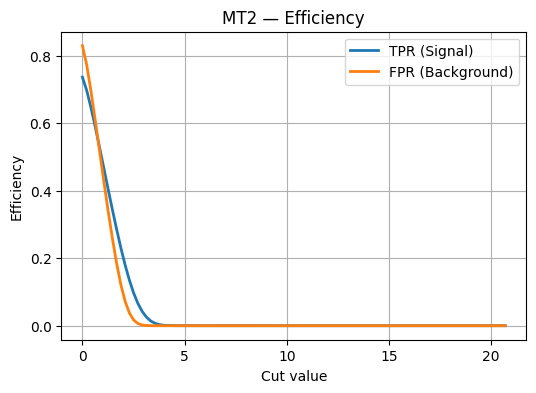

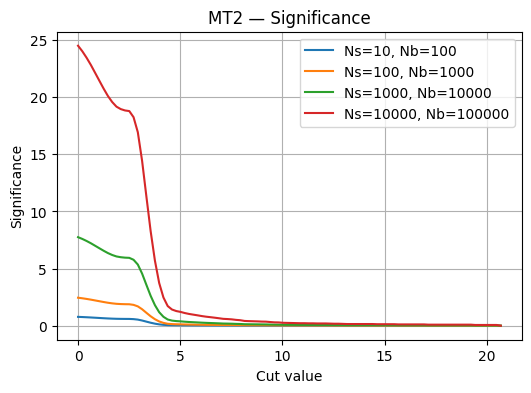

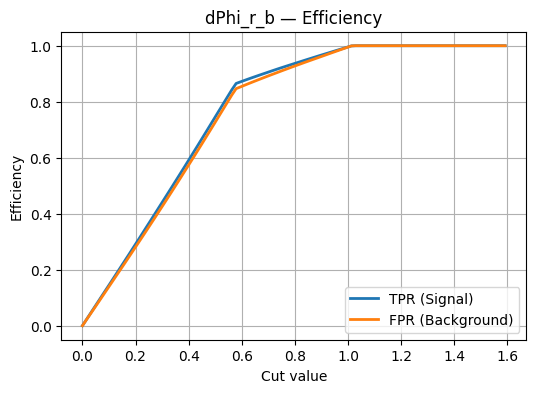

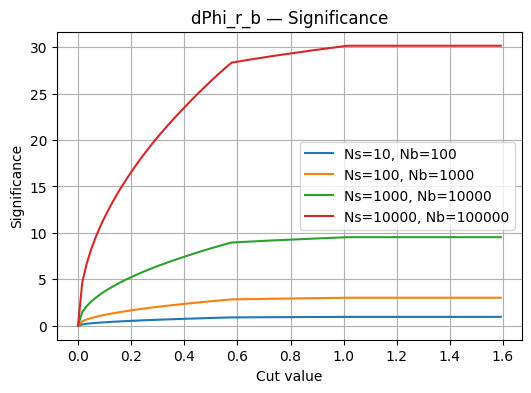

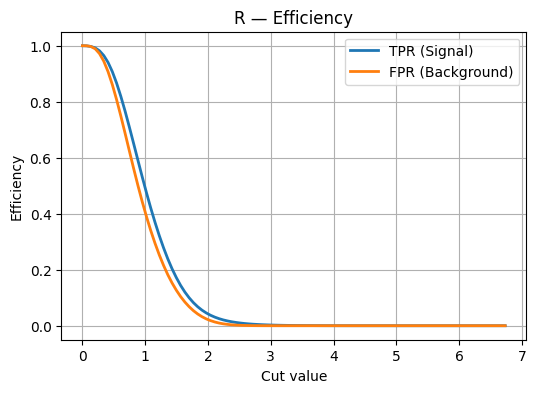

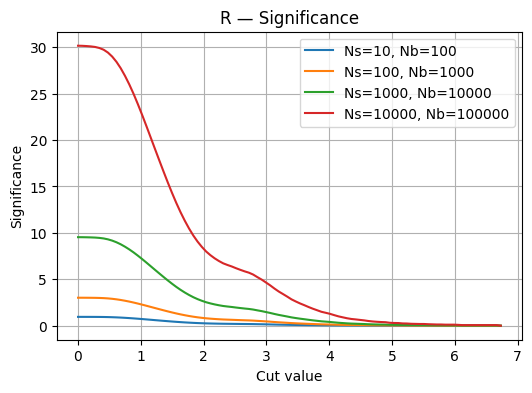

In [140]:
def compute_efficiencies(signal, background, cut_values, strategy, mu=None): # Compute the true positive rate (TPR) and false positive rate (FPR) for a range of cut values based on the specified strategy (greater than, less than, absolute greater than, absolute less than) and an optional mean value for absolute strategies
    eps_s, eps_b = [], []

    for xc in cut_values: # Loop over each cut value in the specified range
        if strategy == "gt":
            s_pass = signal > xc
            b_pass = background > xc

        elif strategy == "lt":
            s_pass = signal < xc
            b_pass = background < xc

        elif strategy == "abs_gt":
            s_pass = np.abs(signal - mu) > xc
            b_pass = np.abs(background - mu) > xc

        elif strategy == "abs_lt":
            s_pass = np.abs(signal - mu) < xc
            b_pass = np.abs(background - mu) < xc

        eps_s.append(np.mean(s_pass))
        eps_b.append(np.mean(b_pass))

    return np.array(eps_s), np.array(eps_b)


def compute_significance(eps_s, eps_b, Ns, Nb): # Compute the significance of a signal given the true positive rate (TPR) for signal, false positive rate (FPR) for background, and the number of signal and background events. The formula used is S = Ns_p / sqrt(Ns_p + Nb_p), where Ns_p and Nb_p are the expected number of signal and background events passing the cut, respectively.
    Ns_p = eps_s * Ns
    Nb_p = eps_b * Nb
    return Ns_p / np.sqrt(Ns_p + Nb_p + 1e-10)

strategy_map = { # Define the strategy for computing efficiencies for each feature. For most features, we want to apply a "greater than" cut, while for some features we want to apply an "absolute less than" cut based on their physical meaning and distributions.
    'l_1_pT': 'gt',
    'l_2_pT': 'gt',
    'MET': 'gt',
    'MT2': 'gt',
    'R': 'gt',

    'l_1_eta': 'abs_lt',
    'l_2_eta': 'abs_lt',
    'l_1_phi': 'abs_lt',
    'l_2_phi': 'abs_lt',
    'MET_phi': 'abs_lt',

    'dPhi_r_b': 'abs_lt'
}

scenarios = [(10,100), (100,1000), (1000,10000), (10000,100000)]

for feature in all_features: # Loop over all features to compute and plot efficiencies and significance for each feature based on the defined strategies and scenarios

    signal = df_sig[feature].values # Extract the values of the current feature for signal and background events to compute efficiencies and significance
    background = df_bkg[feature].values

    min_val = min(signal.min(), background.min()) # Determine the minimum and maximum values across both signal and background for the current feature to define the range of cut values
    max_val = max(signal.max(), background.max())
    cut_values = np.linspace(min_val, max_val, 100)

    strategy = strategy_map.get(feature, "gt") # Get the strategy for the current feature from the strategy map, defaulting to "greater than" if not specified. For absolute strategies, we will need to compute the mean of the signal to use as a reference point for the absolute cuts.

    mu = np.mean(signal) if "abs" in strategy else None # Compute the mean of the signal for absolute strategies to use as a reference point for the cuts, otherwise set it to None

    eps_s, eps_b = compute_efficiencies(signal, background, cut_values, strategy, mu) # Compute the true positive rate (TPR) for signal and false positive rate (FPR) for background across the range of cut values using the specified strategy

    plt.figure(figsize=(6,4)) # Plot the TPR and FPR as a function of the cut value for the current feature to visualize how the efficiency changes with different cuts
    plt.plot(cut_values, eps_s, label="TPR (Signal)", linewidth=2)
    plt.plot(cut_values, eps_b, label="FPR (Background)", linewidth=2)
    plt.xlabel("Cut value")
    plt.ylabel("Efficiency")
    plt.title(f"{feature} — Efficiency")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(6,4)) # Plot the significance as a function of the cut value for different scenarios of signal and background event counts to see how the choice of cut affects the potential discovery significance

    for Ns, Nb in scenarios: # Loop over different scenarios of signal and background event counts to compute and plot the significance for each scenario on the same plot for comparison
        sigma = compute_significance(eps_s, eps_b, Ns, Nb)
        plt.plot(cut_values, sigma, label=f"Ns={Ns}, Nb={Nb}")

    plt.xlabel("Cut value") # Label the x-axis with "Cut value"
    plt.ylabel("Significance")
    plt.title(f"{feature} — Significance")
    plt.legend()
    plt.grid()
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [141]:
def cut_flow(df_sig, df_bkg, features, cuts, strategies, Ns, Nb): # Compute the cut flow table for the specified features, cut values, strategies, and scenarios of signal and background event counts. The function applies the cuts sequentially to both signal and background datasets, computes the efficiencies, expected number of events passing the cuts, and the resulting significance for each feature.
    
    results = []

    sig_mask = np.ones(len(df_sig), dtype=bool)
    bkg_mask = np.ones(len(df_bkg), dtype=bool)

    for i, feature in enumerate(features): # Loop over each feature in the specified order to apply the cuts sequentially and compute the resulting efficiencies and significance after each cut
        xc = cuts[feature]
        strategy = strategies[feature]

        if strategy == "gt":
            sig_mask &= (df_sig[feature] > xc)
            bkg_mask &= (df_bkg[feature] > xc)

        elif strategy == "lt":
            sig_mask &= (df_sig[feature] < xc)
            bkg_mask &= (df_bkg[feature] < xc)

        elif strategy == "abs_lt":
            mu = df_sig[feature].mean()
            sig_mask &= (np.abs(df_sig[feature] - mu) < xc)
            bkg_mask &= (np.abs(df_bkg[feature] - mu) < xc)

        elif strategy == "abs_gt":
            mu = df_sig[feature].mean()
            sig_mask &= (np.abs(df_sig[feature] - mu) > xc)
            bkg_mask &= (np.abs(df_bkg[feature] - mu) > xc)

        eps_s = np.mean(sig_mask)
        eps_b = np.mean(bkg_mask)

        Ns_p = eps_s * Ns
        Nb_p = eps_b * Nb

        sigma = Ns_p / np.sqrt(Ns_p + Nb_p + 1e-10)

        results.append([feature, eps_s, eps_b, Ns_p, Nb_p, sigma])

    return pd.DataFrame(results, columns=[
        "Cut", "ε_S", "ε_B", "N_S'", "N_B'", "Significance"
    ])

cuts = { # Define the optimal cut values for each feature based on the efficiency and significance plots. These values can be chosen to maximize the significance while maintaining a reasonable signal efficiency.
    "MT2": 80,
    "MET": 100,
    "R": 0.5
}

features = ["MT2", "MET", "R"] # Define the features to include in the cut flow table. The order of features determines the sequence of cuts applied, which can affect the resulting efficiencies and significance. We will apply cuts on MT2, MET, and R in that order based on their discriminating power observed in the previous plots.

strategies = { # Define the strategy for computing efficiencies for each feature. For most features, we want to apply a "greater than" cut, while for some features we want to apply an "absolute less than" cut based on their physical meaning and distributions.
    "MT2": "gt",
    "MET": "gt",
    "R": "gt"
}

for Ns, Nb in scenarios: # Loop over different scenarios of signal and background event counts to compute the cut flow table for each scenario and print the results in a formatted table
    table = cut_flow(df_sig, df_bkg, features, cuts, strategies, Ns, Nb)
    
    print(f"\n=== Cut Flow (Ns={Ns}, Nb={Nb}) ===")
    print(table)

# Correlated variables (e.g. MT2 and R) reduce the effectiveness of sequential cuts,
# since cutting on one already constrains the other. Re-optimizing after each cut
# changes the optimal thresholds and shows smaller gains in significance.
# The final result also depends on the order of cuts.


=== Cut Flow (Ns=10, Nb=100) ===
   Cut  ε_S  ε_B  N_S'  N_B'  Significance
0  MT2  0.0  0.0   0.0   0.0           0.0
1  MET  0.0  0.0   0.0   0.0           0.0
2    R  0.0  0.0   0.0   0.0           0.0

=== Cut Flow (Ns=100, Nb=1000) ===
   Cut  ε_S  ε_B  N_S'  N_B'  Significance
0  MT2  0.0  0.0   0.0   0.0           0.0
1  MET  0.0  0.0   0.0   0.0           0.0
2    R  0.0  0.0   0.0   0.0           0.0

=== Cut Flow (Ns=1000, Nb=10000) ===
   Cut  ε_S  ε_B  N_S'  N_B'  Significance
0  MT2  0.0  0.0   0.0   0.0           0.0
1  MET  0.0  0.0   0.0   0.0           0.0
2    R  0.0  0.0   0.0   0.0           0.0

=== Cut Flow (Ns=10000, Nb=100000) ===
   Cut  ε_S  ε_B  N_S'  N_B'  Significance
0  MT2  0.0  0.0   0.0   0.0           0.0
1  MET  0.0  0.0   0.0   0.0           0.0
2    R  0.0  0.0   0.0   0.0           0.0


## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



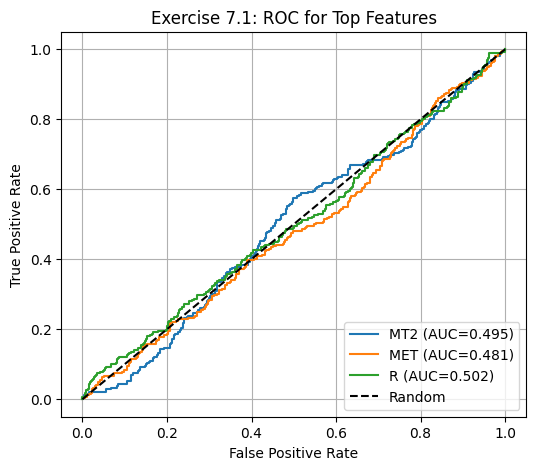

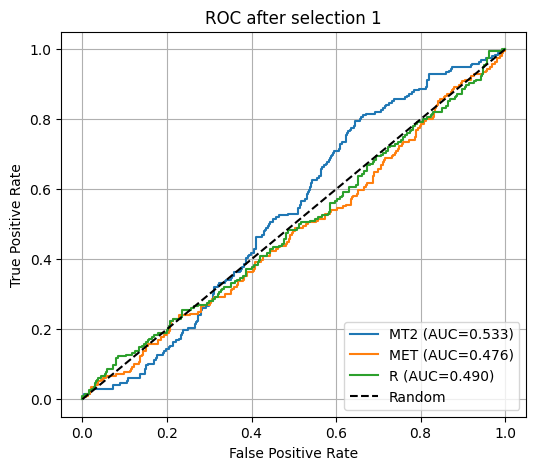

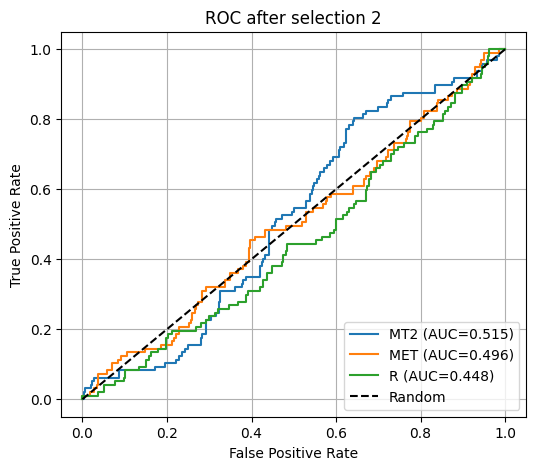

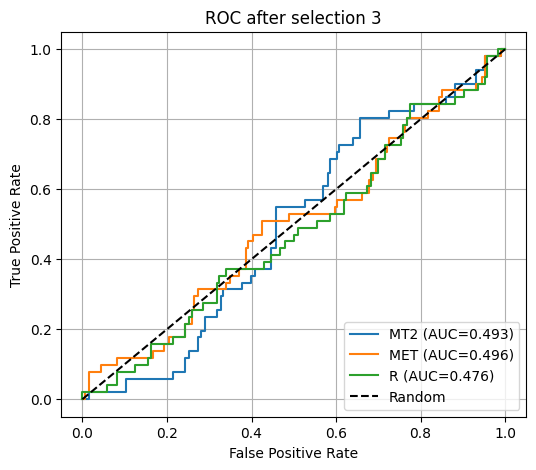

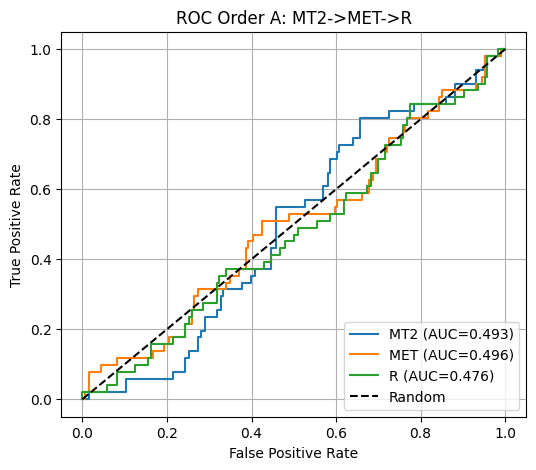

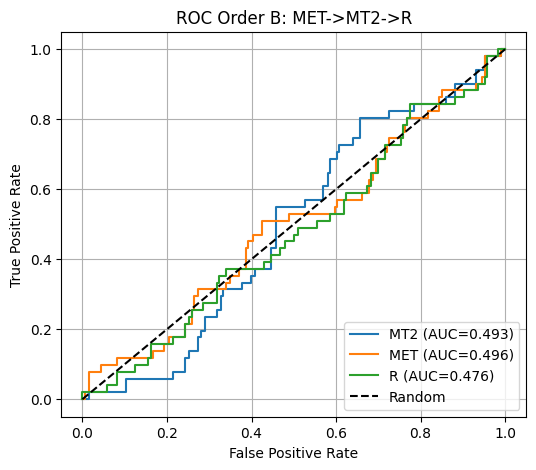

In [142]:
def fast_manual_roc(y_true, scores): # A fast implementation of ROC curve and AUC calculation that sorts the scores and computes the cumulative sums to get TPR and FPR efficiently, without needing to loop over thresholds
    y_true = np.array(y_true)
    scores = np.array(scores)
    
    desc_score_indices = np.argsort(-scores)
    y_true_sorted = y_true[desc_score_indices]
    
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    
    TP_cumsum = np.cumsum(y_true_sorted)
    FP_cumsum = np.cumsum(1 - y_true_sorted)
    
    tpr = TP_cumsum / P
    fpr = FP_cumsum / N
    
    tpr = np.insert(tpr, 0, 0)
    fpr = np.insert(fpr, 0, 0)
    
    auc_val = np.trapezoid(tpr, fpr)
    return fpr, tpr, auc_val

def plot_roc_fast(features, df, label_col='signal', title="ROC Curves"): # A function to plot ROC curves for the specified features using the fast manual ROC implementation. It computes the TPR and FPR for each feature and plots them on the same graph for comparison, along with the AUC values in the legend.
    plt.figure(figsize=(6,5))
    
    for feature in features:
        y_true = df[label_col].values
        scores = df[feature].values
        
        fpr, tpr, auc_val = fast_manual_roc(y_true, scores)
        plt.plot(fpr, tpr, label=f"{feature} (AUC={auc_val:.3f})")
    
    plt.plot([0,1], [0,1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

np.random.seed(42) # Create a simulated dataset with 1000 events, where the features MT2, MET, and R have some separation between signal and background, and the signal is present in about 30% of the events. This dataset will be used to demonstrate the ROC curve plotting and the effect of successive selections.
N = 1000
df = pd.DataFrame({
    "MT2": np.random.normal(5, 2, N) + np.random.binomial(1, 0.3, N)*3,
    "MET": np.random.normal(50, 15, N) + np.random.binomial(1, 0.3, N)*20,
    "R": np.random.uniform(0, 1, N) + np.random.binomial(1, 0.3, N)*0.3,
    "signal": np.random.binomial(1, 0.3, N)
})

top_features = ["MT2", "MET", "R"]

plot_roc_fast(top_features, df, title="Exercise 7.1: ROC for Top Features") # Plot the ROC curves for the top features MT2, MET, and R using the simulated dataset to visualize their discriminating power between signal and background events.

df_sel1 = df[df['MT2'] > 4] # Simulate 3 successive selections by filtering thresholds on features. The first selection is applied on MT2, followed by MET and R, to see how the ROC curve evolves after each selection step.
df_sel2 = df_sel1[df_sel1['MET'] > 55]
df_sel3 = df_sel2[df_sel2['R'] > 0.5]

successive_dfs = [df_sel1, df_sel2, df_sel3] # Store the successive DataFrames after each selection step in a list for easy plotting of ROC curves after each selection.
titles = ["ROC after selection 1", "ROC after selection 2", "ROC after selection 3"]

for df_sel, title in zip(successive_dfs, titles): # Loop over the successive DataFrames after each selection step and plot the ROC curves for the top features to see how the discriminating power changes as we apply more stringent cuts on the dataset.
    plot_roc_fast(top_features, df_sel, title=title)

df_orderA = df[df['MT2'] > 4] # Swap selection order: MT2 -> MET -> R
df_orderA = df_orderA[df_orderA['MET'] > 55]
df_orderA = df_orderA[df_orderA['R'] > 0.5]

df_orderB = df[df['MET'] > 55]
df_orderB = df_orderB[df_orderB['MT2'] > 4]
df_orderB = df_orderB[df_orderB['R'] > 0.5]

plot_roc_fast(top_features, df_orderA, title="ROC Order A: MT2->MET->R") # Plot the ROC curve for the first selection order (MT2 -> MET -> R) to see how the order of cuts affects the resulting dataset and its discriminating power.
plot_roc_fast(top_features, df_orderB, title="ROC Order B: MET->MT2->R")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

Between-class covariance S_B:
 [[ 9.20147932e-03  8.73768902e-02 -6.26627584e-04]
 [ 8.73768902e-02  8.29727556e-01 -5.95043121e-03]
 [-6.26627584e-04 -5.95043121e-03  4.26738045e-05]]
Within-class covariance S_W:
 [[ 5.92719467e+03  2.43115229e+03  1.51588408e+01]
 [ 2.43115229e+03  2.91962327e+05 -1.06925792e+02]
 [ 1.51588408e+01 -1.06925792e+02  1.00722485e+02]]
Linear discriminant coefficients w:
 [ 1.51289930e-05  2.97049219e-06 -6.39801008e-05]


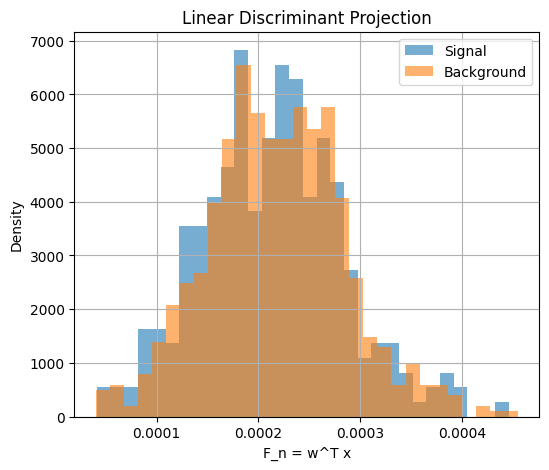

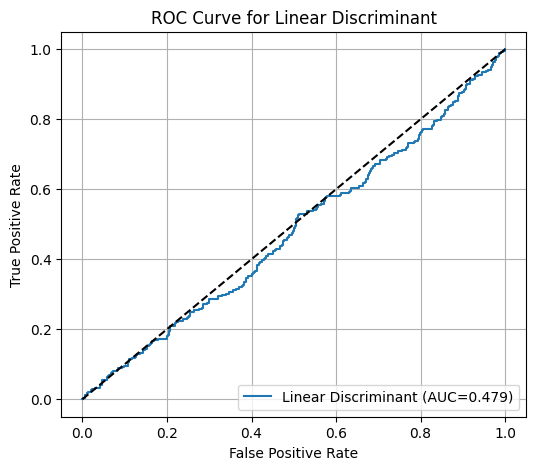

Maximal significance: 8.606 at threshold F_n = 0.000


In [143]:
features = ["MT2", "MET", "R"] # Define the features to use for the linear discriminant analysis. We will use the top features that showed good separation between signal and background in the previous analyses.

X_signal = df[df['signal'] == 1][features].values # Extract the feature values for signal and background events to compute the mean vectors, covariance matrices, and the linear discriminant coefficients for projecting the data onto a 1D space that maximizes the separation between signal and background.
X_bkg = df[df['signal'] == 0][features].values

l1 = X_signal.shape[0] # Number of signal events
l2 = X_bkg.shape[0]

m1 = X_signal.mean(axis=0).reshape(-1,1) # Compute mean vectors for signal and background. We reshape them to be column vectors for the subsequent matrix operations when computing the between-class covariance and the linear discriminant coefficients.
m2 = X_bkg.mean(axis=0).reshape(-1,1)

S_B = (m2 - m1) @ (m2 - m1).T # Compute between-class covariance S_B using the formula S_B = (m2 - m1)(m2 - m1)^T, which captures the separation between the class means in the feature space. This matrix will be used to compute the linear discriminant coefficients that maximize the separation between signal and background.
print("Between-class covariance S_B:\n", S_B)

S_W = np.zeros((len(features), len(features))) # Initialize the within-class covariance S_W as a zero matrix. We will compute S_W by summing the covariance contributions from both signal and background classes, which capture the spread of the data points around their respective class means in the feature space.
for X, m in zip([X_signal, X_bkg], [m1, m2]):
    for x in X:
        x = x.reshape(-1,1)
        S_W += (x - m) @ (x - m).T

print("Within-class covariance S_W:\n", S_W)

w = np.linalg.inv(S_W) @ (m2 - m1) # Compute the linear discriminant coefficients w using the formula w = S_W^-1 (m2 - m1), which gives us the direction in the feature space that maximizes the separation between signal and background when we project the data onto this direction. The resulting w is a vector of coefficients corresponding to each feature, which we will use to compute the linear discriminant score F_n = w^T x for each event.
w = w.flatten()
print("Linear discriminant coefficients w:\n", w)

F_signal = X_signal @ w # Compute the linear discriminant score F_n = w^T x for each signal and background event by projecting the feature vectors onto the linear discriminant coefficients w. This gives us a 1D score for each event that we can use to separate signal from background based on their distributions in this projected space.
F_bkg = X_bkg @ w

plt.figure(figsize=(6,5)) # Plot the histograms of the linear discriminant scores F_n for signal and background events to visualize how well the linear discriminant separates the two classes. We expect to see some separation between the signal and background distributions in this projected space, which indicates that the linear discriminant is effective at capturing the differences between the two classes based on the selected features.
plt.hist(F_signal, bins=30, alpha=0.6, label="Signal", density=True)
plt.hist(F_bkg, bins=30, alpha=0.6, label="Background", density=True)
plt.xlabel("F_n = w^T x")
plt.ylabel("Density")
plt.title("Linear Discriminant Projection")
plt.legend()
plt.grid()
plt.show()

def manual_roc(y_true, scores): # A manual implementation of ROC curve and AUC calculation that sorts the scores and computes the cumulative sums to get TPR and FPR, without using sklearn. This function takes the true labels and the predicted scores, sorts them, and computes the TPR and FPR at each threshold to construct the ROC curve, as well as calculating the AUC using the trapezoidal rule.
    y_true = np.array(y_true)
    scores = np.array(scores)
    desc_idx = np.argsort(-scores)
    y_sorted = y_true[desc_idx]
    P = np.sum(y_true==1)
    N = np.sum(y_true==0)
    TP_cumsum = np.cumsum(y_sorted)
    FP_cumsum = np.cumsum(1 - y_sorted)
    tpr = np.insert(TP_cumsum / P, 0, 0)
    fpr = np.insert(FP_cumsum / N, 0, 0)
    auc_val = np.trapezoid(tpr, fpr)
    return fpr, tpr, auc_val

y_true = df['signal'].values # Get the true labels for all events from the DataFrame to compute the ROC curve and AUC for the linear discriminant scores. We will use the linear discriminant scores F_n computed earlier as the predicted scores for each event, and compare them against the true labels to evaluate the performance of the linear discriminant in separating signal from background.
F_all = df[features].values @ w
fpr, tpr, auc_val = manual_roc(y_true, F_all)

plt.figure(figsize=(6,5)) # Plot the ROC curve for the linear discriminant scores F_n using the manually computed TPR and FPR values. The AUC value is included in the legend to quantify the overall performance of the linear discriminant in separating signal from background, with higher AUC indicating better separation.
plt.plot(fpr, tpr, label=f"Linear Discriminant (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Linear Discriminant")
plt.legend(loc="lower right")
plt.grid()
plt.show()

thresholds = np.sort(np.unique(F_all)) # Compute the significance for a range of thresholds on the linear discriminant scores F_n to find the optimal threshold that maximizes the significance of the signal over background. We will loop over the unique values of F_n as potential thresholds, compute the number of signal and background events that pass each threshold, and calculate the significance using the formula S = Ns_p / sqrt(Ns_p + Nb_p) to identify the threshold that gives us the best separation between signal and background in terms of discovery potential.
max_significance = 0
best_threshold = None

for t in thresholds: # Loop over each threshold value in the sorted unique values of F_n to compute the number of signal and background events that pass the threshold, and calculate the significance for each threshold to find the one that maximizes the significance.
    S = np.sum(F_signal >= t)
    B = np.sum(F_bkg >= t)
    if S + B > 0:
        significance = S / np.sqrt(S + B)
        if significance > max_significance:
            max_significance = significance
            best_threshold = t

print(f"Maximal significance: {max_significance:.3f} at threshold F_n = {best_threshold:.3f}") # Print the maximal significance achieved and the corresponding threshold on the linear discriminant scores F_n that gives this maximal significance, which indicates the optimal cut on the linear discriminant for separating signal from background in terms of discovery potential.